In [1]:
import dill
import os
import numpy as np
import pandas as pd
import pickle
from tabulate import tabulate
import config as cfg
import bdt_lh_cut_opt_with_n_interp

Welcome to JupyROOT 6.28/10


In [3]:
# make final binning plot

#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts['outputDir']['prelim_cuts_full']
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)


#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus
 

In [4]:
print(full_data['EVT_unitThrust_z'])

0         -0.381967
1          0.862386
2         -0.070361
3         -0.019848
4          0.719728
             ...   
5833512   -0.876291
5833956   -0.212840
5834899    0.969073
5837028    0.960909
5837689    0.713836
Name: EVT_unitThrust_z, Length: 5291059, dtype: float32


In [5]:
from post_bdt_variable_plotter import plot_variable
#from post_bdt_application import post_bdt_variable_plot as plot_variable


dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91', 'p8_ee_Zee_ecm91'])
['n_p8_ee_Zbb_ecm91=867253968.3346831', 'n_p8_ee_Zcc_ecm91=1101868015.8614528', 'n_p8_ee_Zss_ecm91=935293148.6978287', 'n_p8_ee_Zud_ecm91=346744932.7437759']
dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91', 'p8_ee_Zee_ecm91'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=150896.20896000002', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=621371.1879098181']


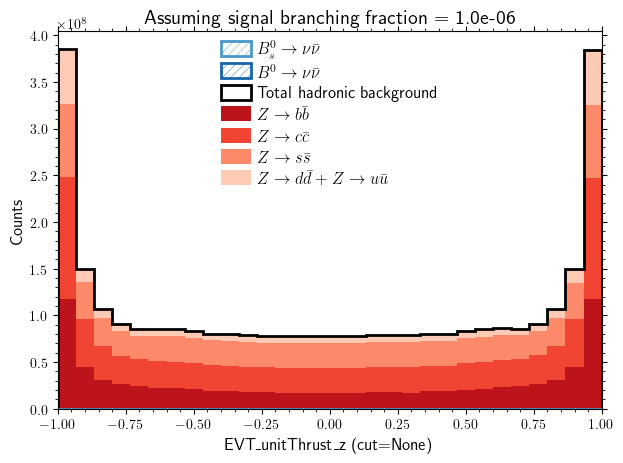

In [6]:
plot_variable(full_data, 'EVT_unitThrust_z', bins=30)

dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91'])
['n_p8_ee_Zbb_ecm91=707169.083902679', 'n_p8_ee_Zcc_ecm91=288843.3389941839', 'n_p8_ee_Zss_ecm91=507690.41841892706', 'n_p8_ee_Zud_ecm91=97636.12455476035']
dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=38461.28832000001', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=168585.56320581815']


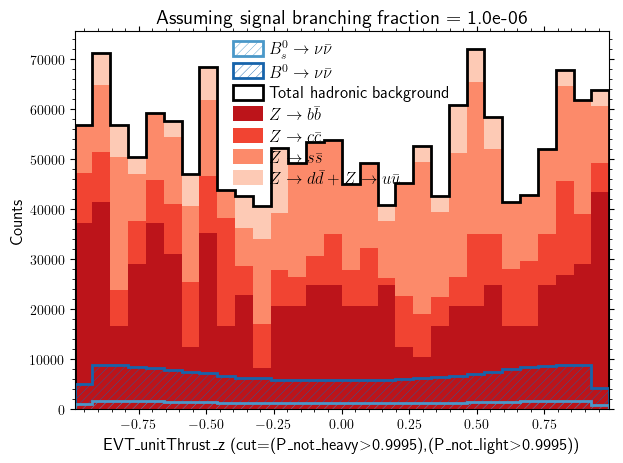

In [7]:
plot_variable(full_data, 'EVT_unitThrust_z', cut = "(P_not_heavy>0.9995)&(P_not_light>0.9995)",bins=30)

dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91'])
['n_p8_ee_Zbb_ecm91=7536933.657383815', 'n_p8_ee_Zcc_ecm91=8025512.173953399', 'n_p8_ee_Zss_ecm91=9899012.428048443', 'n_p8_ee_Zud_ecm91=1676086.8048567197']
dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=95570.16336000002', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=400345.20251345454']


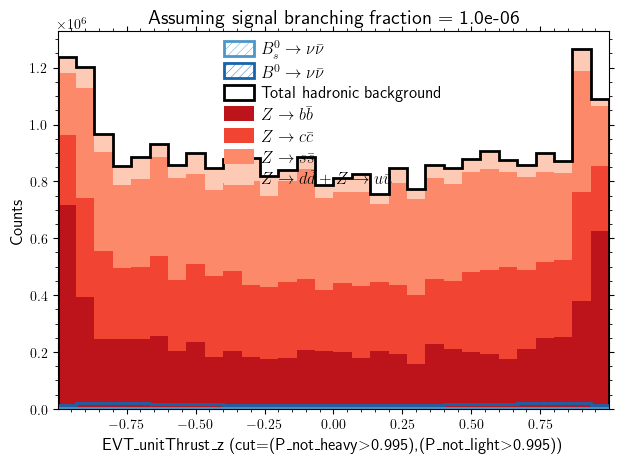

In [8]:
plot_variable(full_data, 'EVT_unitThrust_z', cut = "(P_not_heavy>0.995)&(P_not_light>0.995)",bins=30)